# House Price Prediction

Portfolio version prepared for public GitHub presentation. Student IDs, course-submission wording, and private submission details have been removed.


#### **Question 2**Goal: Predict house prices, `SalePrice`, using a regression model.<br>(If you need any help with this question, please come to the lab session in Week 9.)

In [1]:
import numpy as npimport pandas as pdimport matplotlib.pyplot as plt

In [2]:
# Loading the datasetdata = pd.read_csv('house_prices.csv', index_col='Id')# There are 79 featuresdata.drop('SalePrice', axis=1).shape[1]

79

#### Data preprocessingThe dataset is imperfect, as is commonly seen in the real world.<br> For example, if you type `data.info()`, you will see a brief summary of the Dataframe `data`.As you will notice, many variables contain missing values. But how can we deal with these missing values? Can we simply drop all features that contain them using `data.dropna(axis=1)`? And the Index isn't perfect either. The summary table shows that ``Index: 2908 entries, 1 to 2919.'' How can the Index that spans from 1 to 2919 have only 2908 index positions (rows)? To find the missing indices, you might use the following code:```missing_indices = set(range(1, 2920)) - set(data.index)print(sorted(missing_indices))```

In [3]:
from sklearn.model_selection import train_test_splitfrom sklearn.compose import ColumnTransformerfrom sklearn.pipeline import Pipelinefrom sklearn.impute import SimpleImputerfrom sklearn.preprocessing import OneHotEncoder, StandardScaler# Separate target and featuresX = data.drop('SalePrice', axis=1).copy()y = data['SalePrice'].copy()# Check the imperfect indexmissing_index_values = sorted(set(range(data.index.min(), data.index.max() + 1)) - set(data.index))print("Missing index values:", missing_index_values)# Identify numerical and categorical columnsnum_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()cat_cols = X.select_dtypes(include=['object']).columns.tolist()print("Number of numerical columns:", len(num_cols))print("Number of categorical columns:", len(cat_cols))# Missing values summarymissing_summary = data.isnull().sum()missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)print("\nTop columns with missing values:")print(missing_summary.head(15))# Preprocessing pipelinesnumeric_preprocessor = Pipeline([    ('imputer', SimpleImputer(strategy='median')),    ('scaler', StandardScaler())])categorical_preprocessor = Pipeline([    ('imputer', SimpleImputer(strategy='most_frequent')),    ('onehot', OneHotEncoder(handle_unknown='ignore'))])# Combined preprocessorpreprocessor = ColumnTransformer([    ('num', numeric_preprocessor, num_cols),    ('cat', categorical_preprocessor, cat_cols)])# Train-test splitX_train, X_test, y_train, y_test = train_test_split(    X, y,    test_size=0.2,    random_state=716)print("\nTraining set shape:", X_train.shape)print("Test set shape:", X_test.shape)

Missing index values: [524, 692, 1183, 1299, 1975, 2121, 2217, 2474, 2550, 2574, 2577]Number of numerical columns: 36Number of categorical columns: 43Top columns with missing values:PoolQC          2902MiscFeature     2803Alley           2711Fence           2340MasVnrType      1760FireplaceQu     1416LotFrontage      486GarageCond       158GarageQual       158GarageFinish     158GarageYrBlt      158GarageType       157BsmtCond          80BsmtExposure      80BsmtQual          79dtype: int64Training set shape: (2326, 79)Test set shape: (582, 79)

#### Model selectionWhich model is the best in your view to predict the housing price, `SalePrice`, and why? (Hint: cross validation)?<br>

In [4]:
from sklearn.linear_model import Ridge, Lasso, ElasticNetfrom sklearn.model_selection import GridSearchCV, KFoldfrom sklearn.metrics import mean_squared_error, make_scorerimport numpy as np# Cross validation setupcv = KFold(n_splits=5, shuffle=True, random_state=716)# RMSE scoringrmse_scorer = make_scorer(    lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),    greater_is_better=False)# Ridge pipelineridge_pipe = Pipeline([    ('preprocessor', preprocessor),    ('model', Ridge())])# Lasso pipelinelasso_pipe = Pipeline([    ('preprocessor', preprocessor),    ('model', Lasso(max_iter=20000))])# Elastic Net pipelineenet_pipe = Pipeline([    ('preprocessor', preprocessor),    ('model', ElasticNet(max_iter=20000))])# Hyperparameter gridsridge_grid = {    'model__alpha': [0.01, 0.1, 1, 10, 100]}lasso_grid = {    'model__alpha': [0.001, 0.01, 0.1, 1, 10]}enet_grid = {    'model__alpha': [0.001, 0.01, 0.1, 1, 10],    'model__l1_ratio': [0.2, 0.5, 0.8]}# Grid searchridge_search = GridSearchCV(ridge_pipe, ridge_grid, cv=cv, scoring=rmse_scorer, n_jobs=-1)lasso_search = GridSearchCV(lasso_pipe, lasso_grid, cv=cv, scoring=rmse_scorer, n_jobs=-1)enet_search = GridSearchCV(enet_pipe, enet_grid, cv=cv, scoring=rmse_scorer, n_jobs=-1)# Fit modelsridge_search.fit(X_train, y_train)lasso_search.fit(X_train, y_train)enet_search.fit(X_train, y_train)# Collect resultsmodel_results = pd.DataFrame({    'Model': ['Ridge', 'Lasso', 'Elastic Net'],    'Best CV RMSE': [        -ridge_search.best_score_,        -lasso_search.best_score_,        -enet_search.best_score_    ],    'Best Parameters': [        ridge_search.best_params_,        lasso_search.best_params_,        enet_search.best_params_    ]}).sort_values('Best CV RMSE')model_results

,Model,Best CV RMSE,Best Parameters
2,Elastic Net,21709.269095,"{'model__alpha': 0.01, 'model__l1_ratio': 0.2}"
0,Ridge,21711.834529,{'model__alpha': 10}
1,Lasso,22103.454067,{'model__alpha': 10}


#### Performance evaluationHow well does your model generalize to unseen data? (Hint: Evaluate the model's performance on the test set)

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score# Best model from earlierbest_model = enet_search.best_estimator_# Fit on training databest_model.fit(X_train, y_train)# Predict on test sety_pred = best_model.predict(X_test)# Metricsrmse = np.sqrt(mean_squared_error(y_test, y_pred))mae = mean_absolute_error(y_test, y_pred)r2 = r2_score(y_test, y_pred)print("Test RMSE:", rmse)print("Test MAE:", mae)print("Test R²:", r2)

Test RMSE: 19974.941592989828Test MAE: 13898.197642882806Test R²: 0.9328474195164436

# =========================# Prediction visualization# =========================

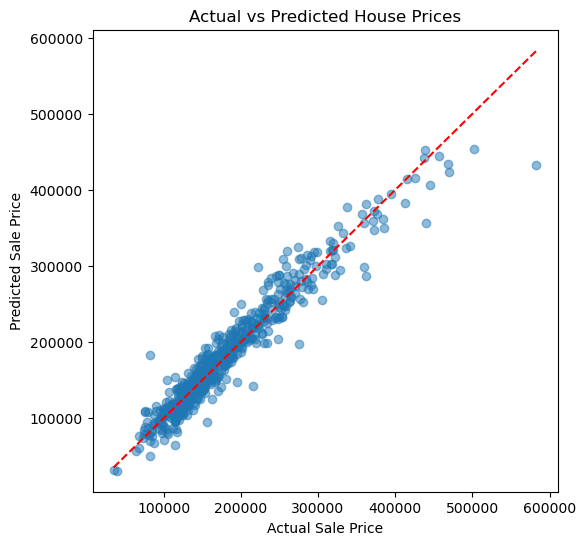

In [6]:
import matplotlib.pyplot as pltplt.figure(figsize=(6,6))plt.scatter(y_test, y_pred, alpha=0.5)plt.xlabel("Actual Sale Price")plt.ylabel("Predicted Sale Price")plt.title("Actual vs Predicted House Prices")plt.plot(    [y_test.min(), y_test.max()],    [y_test.min(), y_test.max()],    'r--')plt.show()

# =========================# Feature importance# =========================

<!-- Have you learned how to write a paragraph in Markdown? If not, this is a great opportunity to do so!  -->

In [7]:
# Extract modelelastic_model = best_model.named_steps['model']# Get feature names after preprocessingfeature_names = best_model.named_steps['preprocessor'].get_feature_names_out()# Extract coefficientscoefficients = elastic_model.coef_# Build dataframecoef_df = pd.DataFrame({    "Feature": feature_names,    "Coefficient": coefficients})# Sort by absolute importancecoef_df["AbsCoef"] = coef_df["Coefficient"].abs()coef_df = coef_df.sort_values("AbsCoef", ascending=False)# Top 10 featurestop_features = coef_df.head(10)top_features

,Feature,Coefficient,AbsCoef
85,cat__Neighborhood_StoneBr,22144.507646,22144.507646
78,cat__Neighborhood_NoRidge,16715.085884,16715.085884
15,num__GrLivArea,16134.228138,16134.228138
163,cat__ExterQual_Ex,15444.384923,15444.384923
220,cat__KitchenQual_Ex,12579.011388,12579.011388
178,cat__BsmtQual_Ex,11612.356083,11612.356083
13,num__2ndFlrSF,11581.540803,11581.540803
3,num__OverallQual,11394.895795,11394.895795
134,cat__Exterior1st_BrkFace,11048.324649,11048.324649
187,cat__BsmtExposure_Gd,10616.959360,10616.959360


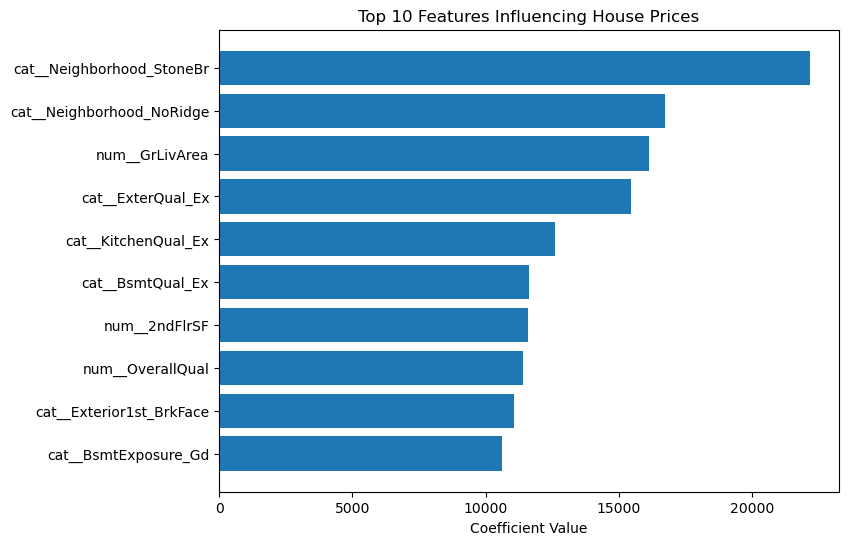

In [8]:
plt.figure(figsize=(8,6))plt.barh(    top_features["Feature"],    top_features["Coefficient"])plt.gca().invert_yaxis()plt.title("Top 10 Features Influencing House Prices")plt.xlabel("Coefficient Value")plt.show()

## Interpretation of findingsThe Elastic Net regression model achieved the best predictive performance, producing a test RMSE of approximately $19,975 and an R² of 0.933. This indicates that the model is able to explain about 93% of the variation in house prices, suggesting strong predictive capability.The most influential features identified by the model highlight three main drivers of house prices: location, property size, and construction quality. Houses located in premium neighborhoods such as Stone Brook and Northridge tend to command significantly higher prices. Property size variables, particularly above-ground living area and second-floor space, also have strong positive effects on price, reflecting the importance of usable living space. In addition, quality indicators such as exterior quality, kitchen quality, basement quality, and overall house quality are major contributors to property value.Overall, these findings are consistent with economic intuition in the housing market, where desirable locations, larger living spaces, and higher construction quality typically lead to higher property prices.